# Интеллектуальный анализ данных – весна 2026
# Домашнее задание 6: классификация текстов

Правила:



*   Домашнее задание оценивается в 10 баллов.
*   Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.
*  Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
*  Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
*  Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.
* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [210]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [211]:
df = pd.read_csv('tweets_coronavirus.csv', encoding='latin-1')
df.sample(4)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
10723,16811,61763,"East, England",21-03-2020,The panic buying has got to stop. My dad has k...,Extremely Negative
29166,39590,84542,"Gangarampur, India",9/4/2020,@Canon_India .@Canon_India never fails 2 surpr...,Positive
16792,24244,69196,NaN,25-03-2020,@SuperCoupleGal Definitely agree! They tell yo...,Extremely Positive
17799,25451,70403,"East, England",25-03-2020,"Wow, everyone seems to be a key worker these d...",Positive


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная или очень положительная эмоциональная окраска и 0 - если отрицательная или очень отрицательная.

In [212]:
df["Sentiment"] = df["Sentiment"].map({"Positive": 1, "Extremely Positive": 1, "Negative": 0, "Extremely Negative": 0})

Сбалансированы ли классы?

In [213]:
df["Sentiment"].value_counts()

Sentiment
1    18046
0    15398
Name: count, dtype: int64

**Ответ:** классы являются сбалансированными, с небольшим перевесом в сторону положительно окрашенных сообщений, но не критичным

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [214]:
df.isnull().sum()

UserName            0
ScreenName          0
Location         7049
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64

In [215]:
df = df.fillna("Unknown")

Разделите данные на обучающие и тестовые в соотношении 7 : 3 и укажите `random_state=0`

In [216]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size = 0.3, random_state = 0)

## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведения токенов в нижний регистр.

In [217]:
from collections import Counter

token_counts = Counter()
for tweet in train['OriginalTweet']:
    tokens = tweet.lower().split()
    token_counts.update(tokens)
token_counts

Counter({'the': 26809,
         'to': 23372,
         'and': 14683,
         'of': 13010,
         'a': 11741,
         'in': 11197,
         'for': 8564,
         '#coronavirus': 8222,
         'is': 7382,
         'are': 7049,
         'you': 5465,
         'on': 5452,
         'i': 5337,
         'at': 4640,
         'this': 4581,
         'with': 4063,
         'prices': 3889,
         'food': 3820,
         'we': 3787,
         'have': 3768,
         'that': 3739,
         'as': 3694,
         'be': 3569,
         'grocery': 3469,
         'supermarket': 3287,
         'people': 3174,
         'covid-19': 3173,
         'store': 3155,
         'it': 3150,
         'from': 3044,
         'all': 2808,
         'your': 2784,
         'will': 2726,
         'not': 2712,
         '#covid19': 2470,
         'our': 2460,
         'my': 2444,
         '&amp;': 2314,
         'they': 2309,
         'has': 2304,
         'consumer': 2245,
         'by': 2236,
         'or': 2234,
         '

Какой размер словаря получился?

In [218]:
len(token_counts)

79742

Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе.

In [219]:
token_counts.most_common(10)

[('the', 26809),
 ('to', 23372),
 ('and', 14683),
 ('of', 13010),
 ('a', 11741),
 ('in', 11197),
 ('for', 8564),
 ('#coronavirus', 8222),
 ('is', 7382),
 ('are', 7049)]

**Ответ:** в топе в основном местоимения, союзы, артикли и предлоги, которые сами по себе не являются носителями информации, однако для построения сообщения их использование необходимо.

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [220]:
!pip install nltk


[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: C:\Users\Виктор\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [221]:
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")

stop_words = stopwords.words("english")
filtered_token_counts = Counter({token: count for token, count in token_counts.items() if token not in stop_words})
filtered_token_counts.most_common(10)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Виктор\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('#coronavirus', 8222),
 ('prices', 3889),
 ('food', 3820),
 ('grocery', 3469),
 ('supermarket', 3287),
 ('people', 3174),
 ('covid-19', 3173),
 ('store', 3155),
 ('#covid19', 2470),
 ('&amp;', 2314)]

**Ответ:**  теперь топ-10 в наибольшей степени отражает ключевые темы, важные для пользователей соцсети в пандемию коронавируса. 

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше, выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [222]:
least_common = sorted(filtered_token_counts.items(), key=lambda x: x[1])[:20]
least_common

[('https://t.co/1m881cwfuv', 1),
 ('happy..', 1),
 ('https://t.co/z0intks34x', 1),
 ('mnuchinã\x82â\x92s', 1),
 ('brink.', 1),
 ('https://t.co/jmobv8z0u0', 1),
 ("university's", 1),
 ('teaching.)', 1),
 ('@catholicpres', 1),
 ('@catholicuniv', 1),
 ('https://t.co/evqby035wf', 1),
 ('https://t.co/riqrhxxeim', 1),
 ('@@ballardspahrll', 1),
 ('#aca', 1),
 ('easier...take', 1),
 ('ã\x82â\x93necessaryã\x82â\x94', 1),
 ('https://t.co/0fmsmlgepm', 1),
 ('husted:', 1),
 ('irishman', 1),
 ('#happystpatricksday!', 1)]

**Ответ:** среди самых непопулярных токенов преимущественно ссылки, хэштеги и случайные символы. Эти токены не позволяют установить закономерности и не помогают обучить модель. Такие токены лучше удалить, чтобы не мешали процессу обучения, или сделать лемматизацию или стемминг.


Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [223]:
from nltk.tokenize import TweetTokenizer

token_counts = Counter()
tw = TweetTokenizer()
for tweet in train['OriginalTweet']:
    tokens = tw.tokenize(tweet)
    token_counts.update(tokens)
token_counts.most_common(10)

[('the', 24331),
 ('.', 24106),
 ('to', 22932),
 (',', 17569),
 ('and', 14353),
 ('of', 12902),
 ('a', 11049),
 ('in', 10572),
 ('?', 9522),
 ('for', 8226)]

**Ответ:** теперь он также успешно выделяет знаки пунктуации и иные спецсимволы, что и можно наблюдать в топе.

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [224]:
from string import punctuation

noise = stopwords.words("english") + list(punctuation)
filtered_token_counts = Counter({token: count for token, count in token_counts.items() if token not in noise})
filtered_token_counts.most_common(10)

[('Â', 7402),
 ('\x82', 7298),
 ('19', 7167),
 ('#coronavirus', 7142),
 ('I', 5235),
 ('\x92', 4370),
 ('prices', 4279),
 ('COVID', 4217),
 ('food', 3795),
 ('store', 3691)]

**Ответ:** да, есть теперь какие-то странные наборы символов

Скорее всего в некоторых топах были неотображаемые символы или отдельные буквы не латинского алфавита. Уберем их: удалите из словаря токены из одного символа, позиция которого в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [225]:
final_filtered_token_counts = Counter({token: count for token, count in filtered_token_counts.items() if not (len(token) == 1 and ord(token) >= 128)})
final_filtered_token_counts.most_common(10)

[('19', 7167),
 ('#coronavirus', 7142),
 ('I', 5235),
 ('prices', 4279),
 ('COVID', 4217),
 ('food', 3795),
 ('store', 3691),
 ('supermarket', 3371),
 ('grocery', 3083),
 ('people', 3045)]

In [226]:
sorted(final_filtered_token_counts.items(), key=lambda x: x[1])[:20]

[('https://t.co/1m881CwFUv', 1),
 ('https://t.co/Z0intkS34x', 1),
 ('MnuchinÃ', 1),
 ('https://t.co/JmoBv8z0U0', 1),
 ("University's", 1),
 ('@CatholicPres', 1),
 ('@CatholicUniv', 1),
 ('https://t.co/EvQby035wF', 1),
 ('https://t.co/rIQrhxxeIM', 1),
 ('@BallardSpahrLL', 1),
 ('#training', 1),
 ('#aca', 1),
 ('https://t.co/0FmSmlGePM', 1),
 ('Irishman', 1),
 ('#HappyStPatricksDay', 1),
 ('Guiness', 1),
 ('https://t.co/18V0PYHwb7', 1),
 ('https://t.co/LS0g86i8PU', 1),
 ('https://t.co/oFVkejfF23', 1),
 ('https://t.co/Xoodgd2uLx', 1)]

**Ответ:** теперь стало лучше в плане неотображаемых символов и случайного набора символов, стало меньше мусора. Также он лучше выделяет действительно частотные слова, однако он стал пропускать некоторые местоимения, числа и иные спецсимволы. Также никак не решена проблема попадания ссылок в качестве токенов.

Выведите топ-10 популярных хештегов (токены, первые символы которых - #) с количеством встреч. Что можно сказать о них?

In [227]:
hashtags = Counter({token: count for token, count in final_filtered_token_counts.items() if token.startswith("#")})
hashtags.most_common(10)

[('#coronavirus', 7142),
 ('#COVID19', 1843),
 ('#Covid_19', 1462),
 ('#Coronavirus', 1280),
 ('#COVID2019', 926),
 ('#toiletpaper', 657),
 ('#covid19', 568),
 ('#COVID', 540),
 ('#CoronaCrisis', 426),
 ('#CoronaVirus', 351)]

**Ответ:** 9/10 хештегов - на одну и ту же тему.

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [228]:
links = Counter({token: count for token, count in final_filtered_token_counts.items() if token.startswith("https://t.co")})
links.most_common(10)

[('https://t.co/oXA7SWtoNd', 5),
 ('https://t.co/gP3EusapL8', 4),
 ('https://t.co/DefTruI1PfÃ\x82Â', 3),
 ('https://t.co/WrLHYzIzAA', 3),
 ('https://t.co/kuwIpF1KQW', 3),
 ('https://t.co/zjNRx6dKKN', 3),
 ('https://t.co/3GBBDpdjat', 3),
 ('https://t.co/e2ZNXajPre', 3),
 ('https://t.co/CATKegAyOY', 3),
 ('https://t.co/G63RP042HO', 3)]

**Ответ:** нет, ссылки по сути уникальны и не дают никакой информации, а их популярность совершенно несоизмерима с хештегами.

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для  выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа с позицией в таблице Unicode 128 и более,  ссылки на t.co



In [229]:
def custom_tokenizer(text):
    tweet = text.lower()
    tkns = TweetTokenizer().tokenize(tweet)
    tokens = [token for token in tkns if (token not in noise) and not (len(token) == 1 and ord(token) >= 128) and not (token.startswith("https://t.co"))]
    return tokens

In [230]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample', 'text', '@sample_text', '#sampletext']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [231]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(tokenizer = custom_tokenizer)
X_train_vec = cv.fit_transform(train["OriginalTweet"])
print(len(cv.vocabulary_))

C:\Users\Виктор\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


45280


**Ответ:** он стал меньше, чем был в начале задания 2, что логично, так как мы избавились от стоп-слов, пунктуации и прочего мусора.

Посмотрим на какой-нибудь конкретный твитт:

In [232]:
ind = 9023
train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']

('Nice one @SkyNews lets not panic but show ppl in france queueing for food!!! #CoronavirusOutbreak #COVID2019 brainless!! Ffs',
 np.int64(0))

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [233]:
text = train.iloc[ind]['OriginalTweet']
vec = cv.transform([text])
for token in custom_tokenizer(text):
    print(f"{token}: {vec[0, cv.vocabulary_[token]]}")

nice: 1
one: 1
@skynews: 1
lets: 1
panic: 1
show: 1
ppl: 1
france: 1
queueing: 1
food: 1
#coronavirusoutbreak: 1
#covid2019: 1
brainless: 1
ffs: 1


**Ответ:** нуу, каждый токен встречается по одному разу. Модель, реагируя на частность токена, игнорирует смысловую значимость токена, и по сути, в рамках такой метода можно назвать два любых токена из этого списка и назвать их важными и неважными. Разумеется, они не сформулировались хорошо.

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [234]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidfv = TfidfVectorizer(tokenizer=custom_tokenizer, token_pattern=None)
tfidfv.fit(train["OriginalTweet"])

def token_importance(text):
    vector = tfidfv.transform([text])
    series = pd.Series()
    for token in custom_tokenizer(text):
        series[token] = vector[0, tfidfv.vocabulary_[token]]
    return series

vec = token_importance(text)
print(f"Самый важный: {vec.idxmax()} ({vec.max():.2f})")
print(f"Самый неважный: {vec.idxmin()} ({vec.min():.2f})")

Самый важный: brainless (0.39)
Самый неважный: food (0.11)


**Ответ:** теперь стало лучше, по самому важному токену мы явно можем понять, что у твита негативный окрас, а самый неважный токен часто встречается в этом и других твитах.

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [235]:
train[train['OriginalTweet'].apply(lambda x: 'amazing' in x) & (train['Sentiment'] == 1)]

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
4583,9362,54314,"Moulton, England",19-03-2020,Hearing so many stories of NHS heroes Teachers...,1
8221,13787,58739,Unknown,20-03-2020,Let s just take a minute to say THANK YOU also...,1
3183,7654,52606,"London, England",18-03-2020,"Back at the ""Frontline""\r\r\nA massive shout o...",1
24347,33577,78529,Unknown,5/4/2020,Massive thanks to @waitrose for my delivery of...,1
3281,7772,52724,"Nairobi, Kenya",18-03-2020,Crisp clean fresh air perfect ambience Covid 1...,1
...,...,...,...,...,...,...
8199,13757,58709,Wrightington,20-03-2020,The support from customers this week has been ...,1
11636,17911,62863,Australia,21-03-2020,"Margot Robbie is an amazing actress, and love ...",1
23018,31918,76870,"Karachi, Pakistan",4/4/2020,Face Mask (Pack of 5) ÃÂ Meeting the need of...,1
5208,10126,55078,Unknown,19-03-2020,There's some amazing work going on in the worl...,1


In [236]:
text = train[train['UserName'] == 7772].OriginalTweet.iloc[0]
print(text)

Crisp clean fresh air perfect ambience Covid 19 measures in place and amazing food kama kawaida Don t panic rest easy with us


In [237]:
vec = token_importance(text)
print(f"Самый важный: {vec.idxmax()} ({vec.max():.2f})")
print(f"Самый неважный: {vec.idxmin()} ({vec.min():.2f})")

Самый важный: ambience (0.36)
Самый неважный: 19 (0.08)


**Ответ:** самый важный токен в этом примере - ambience (атмосфера).

## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [238]:
y_train = train["Sentiment"]
y_test = test["Sentiment"]
X_train_count = cv.fit_transform(train["OriginalTweet"])
X_test_count = cv.transform(test["OriginalTweet"])
X_train_tfidf = tfidfv.fit_transform(train["OriginalTweet"])
X_test_tfidf = tfidfv.transform(test["OriginalTweet"])

C:\Users\Виктор\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

Используйте `sparse` матрицы (после векторизации), не превращайте их в `numpy.ndarray` или `pd.DataFrame` - может не хватить памяти.

In [239]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def scores(X_train, X_test):
    model = LogisticRegression()
    model.fit(X_train, y_train)
    return accuracy_score(y_train, model.predict(X_train)), accuracy_score(y_test, model.predict(X_test))

print("CountVectorizer:")
print("На обучающей, на тестовой", scores(X_train_count, X_test_count))
print("TF-IDF:")
print("На обучающей, на тестовой", scores(X_train_tfidf, X_test_tfidf))

CountVectorizer:
На обучающей, на тестовой (0.9843229389149936, 0.8674506677297189)
TF-IDF:
На обучающей, на тестовой (0.9220845792396412, 0.8524018337651983)


**Ответ:** лучший результат показала модель CountVectorizer, однако заметно, что она сильно переобучается на обучающей выборке. TF-IDF за счёт того, что уменьшает вес у неважных и малоинформативных токенов, является более стабильной моделью.

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [240]:
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer("english")
def custom_stem_tokenizer(text):
  tokens = list(map(stemmer.stem, custom_tokenizer(text)))
  return tokens

In [241]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word', 'check', 'stem']

In [242]:
cv = CountVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None)
cv.fit(train['OriginalTweet'])
print(len(cv.vocabulary_))

36622


**Ответ**: размер словаря ещё уменьшился, что связано с тем, что мы отбросили производные формы, оставив только слова в основной форме.

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [243]:
tfidfv = TfidfVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None)
tfidfv.fit(train['OriginalTweet'])
y_train = train["Sentiment"]
y_test = test["Sentiment"]
X_train_count = cv.fit_transform(train["OriginalTweet"])
X_test_count = cv.transform(test["OriginalTweet"])
X_train_tfidf = tfidfv.fit_transform(train["OriginalTweet"])
X_test_tfidf = tfidfv.transform(test["OriginalTweet"])

print("CountVectorizer:")
print("На обучающей, на тестовой", scores(X_train_count, X_test_count))
print("TF-IDF:")
print("На обучающей, на тестовой", scores(X_train_tfidf, X_test_tfidf))

CountVectorizer:
На обучающей, на тестовой (0.9717214865442119, 0.8672513454255532)
TF-IDF:
На обучающей, на тестовой (0.9152926099957284, 0.8560892963922663)


**Ответ:** качество практически не изменилось, стали чуть меньше переобучаться, смысл есть, но незначительный.

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

In [244]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer, max_df=8500).fit(train['OriginalTweet'])
print(len(cv_df.vocabulary_))

C:\Users\Виктор\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


36621


**Ответ:** параметр получился небольшим (меньше трети), что говорит о том, что практически нет таких токенов, которые встречаются в значительной доле твитов сразу, что говорит о том, что в рамках одной большой темы существуют твиты 

Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [245]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer, min_df=11).fit(train['OriginalTweet'])
print(len(cv_df.vocabulary_))

3689


In [246]:
cv_df_X = cv_df.transform(train.OriginalTweet)
cv_df_test_X = cv_df.transform(test.OriginalTweet)
print(scores(cv_df_X, cv_df_test_X))

(0.9294318667236224, 0.8679489734901336)


**Ответ:** ну, в целом получились норм результаты, удивительно похожи на то, что было ранее.

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `barplot`, содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

In [247]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(with_mean=False)
cv_df_X = scaler.fit_transform(cv_df_X)
cv_df_test_X = scaler.transform(cv_df_test_X)
model = LogisticRegression(max_iter=10_000)
train_predict = model.fit(cv_df_X, y_train).predict(cv_df_X)
test_predict = model.predict(cv_df_test_X)
print(accuracy_score(y_train, train_predict), accuracy_score(y_test, test_predict))

0.9410508329773601 0.8436316523819015


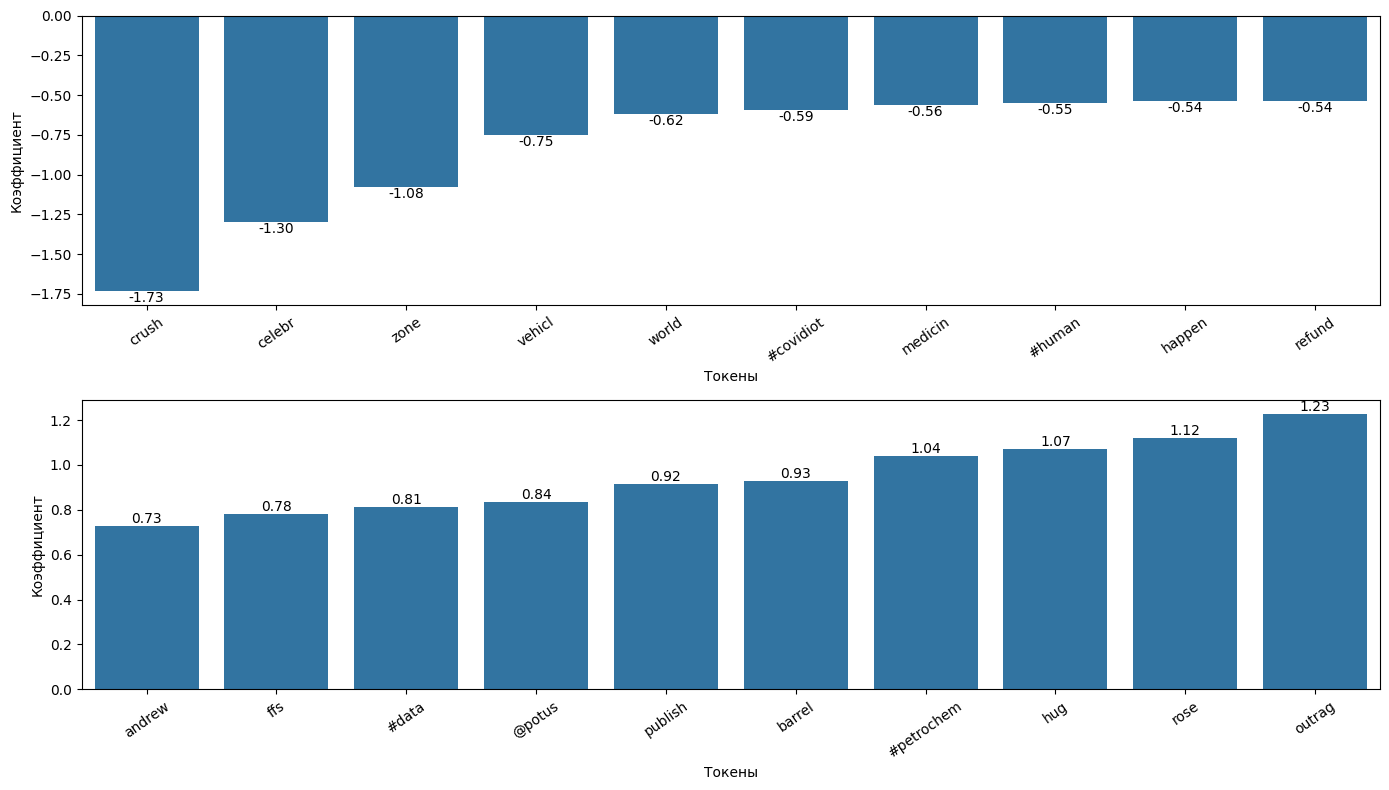

In [248]:
coefs = pd.Series(model.coef_[0], index=cv_df.vocabulary_).sort_values()
top_negative = coefs.head(10)
top_positive = coefs.tail(10)
plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
bars_neg = sns.barplot(x=top_negative.index, y=top_negative.values)
plt.xlabel("Токены")
plt.ylabel("Коэффициент")
plt.xticks(rotation=35)
for i, value in enumerate(top_negative.values):
    plt.text(i, value, f"{value:.2f}", ha="center", va="top")
plt.subplot(2, 1, 2)
bars_pos = sns.barplot(x=top_positive.index, y=top_positive.values)
plt.xlabel("Токены")
plt.ylabel("Коэффициент")
plt.xticks(rotation=35)
for i, value in enumerate(top_positive.values):
    plt.text(i, value, f"{value:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Ответ:** ну качество немного просело, что не есть хорошо. Ну токены с наибольшими положительными/отрицательными весами несколько странные, не совсем понятно по некоторым, почему они позитивно или негативно окрашивают.

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [249]:
print(df[["UserName", "ScreenName"]].describe())
username_counts = df['UserName'].value_counts()
screenname_counts = df['ScreenName'].value_counts()
print(username_counts[username_counts > 1].shape[0])
print(screenname_counts[screenname_counts > 1].shape[0])

           UserName    ScreenName
count  33444.000000  33444.000000
mean   24233.721863  69185.721863
std    11875.552641  11875.552641
min     3800.000000  48752.000000
25%    13964.750000  58916.750000
50%    24159.500000  69111.500000
75%    34514.250000  79466.250000
max    44955.000000  89907.000000
0
0


**Ответ:** эти значения уникальны и случайны, они никак не помогут в обучении.

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на основе целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

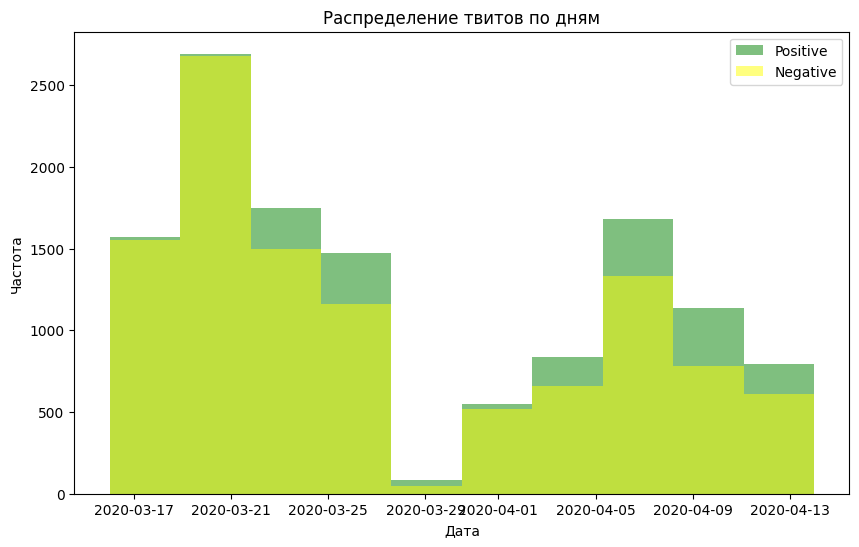

In [250]:
train["TweetAt"] = (train["TweetAt"].astype(str).str.strip().str.replace("/", "-", regex=False))
train["TweetAt"] = pd.to_datetime(train["TweetAt"], format="%d-%m-%Y", errors="coerce")
train_positive = train[train['Sentiment'] == 1]
train_negative = train[train['Sentiment'] == 0]
plt.figure(figsize=(10, 6))
plt.hist(train_positive['TweetAt'], alpha=0.5, label='Positive', color='green')
plt.hist(train_negative['TweetAt'], alpha=0.5, label='Negative', color='yellow')
plt.title('Распределение твитов по дням')
plt.xlabel('Дата')
plt.ylabel('Частота')
plt.legend()
plt.show()

In [251]:
from scipy.sparse import csr_matrix, hstack

train['Month'] = train['TweetAt'].dt.month
train_month = csr_matrix(scaler.fit_transform(train['Month'].values.reshape(-1, 1)))
X_train_new = hstack([cv_df_X, train_month])

test["TweetAt"] = (test["TweetAt"].astype(str).str.strip().str.replace("/", "-", regex=False))
test["TweetAt"] = pd.to_datetime(test["TweetAt"], format="%d-%m-%Y", errors="coerce")
test['Month'] = test['TweetAt'].dt.month
test_month = csr_matrix(scaler.fit_transform(test['Month'].values.reshape(-1, 1)))
X_test_new = hstack([cv_df_test_X, test_month])

In [252]:
model = LogisticRegression(max_iter=10_000)
train_predict = model.fit(X_train_new, y_train).predict(X_train_new)
test_predict = model.predict(X_test_new)
print(accuracy_score(y_train, train_predict), accuracy_score(y_test, test_predict))

0.9410081161896625 0.8436316523819015


**Ответ:** ну, как можно видеть, параметр погоды не делает, так что значимость его сомнительна.

Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [253]:
len(train['Location'].unique())

7949

Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

C:\Users\Виктор\AppData\Local\Temp\ipykernel_816\3779110143.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


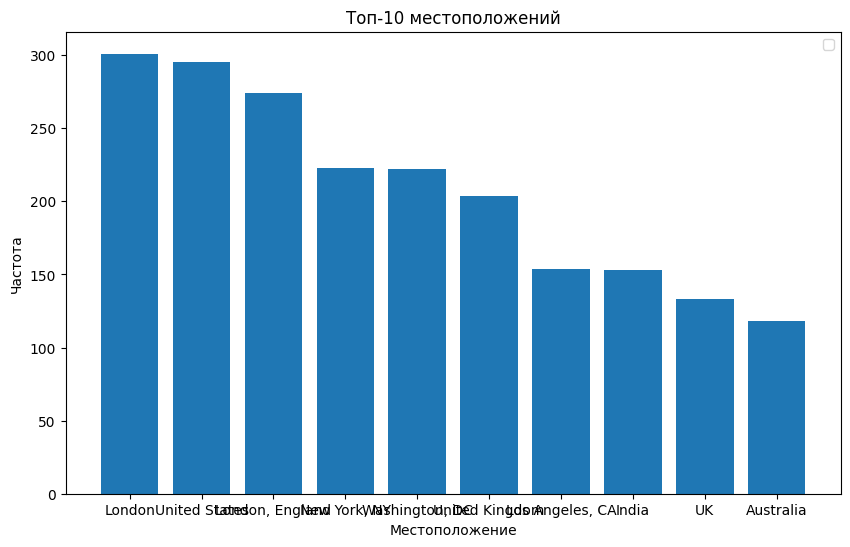

In [254]:
loc_dict = dict(train['Location'].value_counts()[1:11])
plt.figure(figsize=(10, 6))
plt.bar(loc_dict.keys(), loc_dict.values())
plt.title('Топ-10 местоположений')
plt.xlabel('Местоположение')
plt.ylabel('Частота')
plt.legend()
plt.show()

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

In [255]:
import re

df['WiderLocation'] = df['Location'].apply(lambda x: re.sub(r'[^,\w\s]', '', x))
df['WiderLocation'] = df['WiderLocation'].apply(lambda x: x.split(',')[-1].strip())
df['WiderLocation'].nunique()

5785

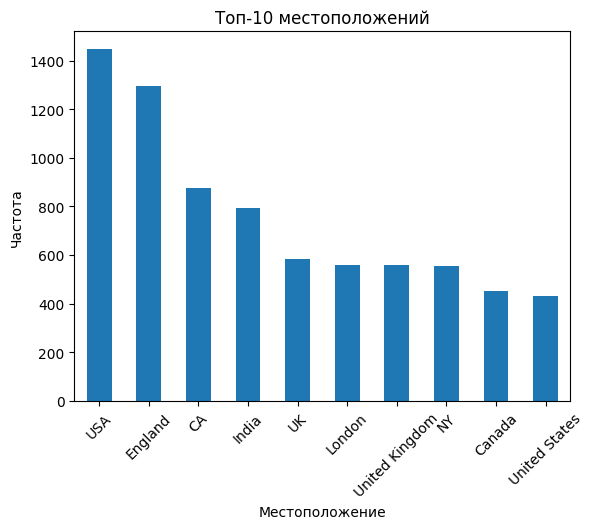

In [256]:
df['WiderLocation'].value_counts()[1:11].plot(kind='bar')
plt.title('Топ-10 местоположений')
plt.xlabel('Местоположение')
plt.ylabel('Частота')
plt.xticks(rotation=45)
plt.show()

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


In [257]:
count = df['WiderLocation'].value_counts()
freq_loc = count[count > 1].index.tolist()
freq_loc.pop(0) 
len(freq_loc)

1263

In [258]:
train['WiderLocation'] = df.loc[train.index, 'WiderLocation']
test['WiderLocation'] = df.loc[test.index, 'WiderLocation']

In [259]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

encoder = OneHotEncoder(categories=[freq_loc], drop='if_binary', handle_unknown='ignore', sparse_output=True)
train_loc = encoder.fit_transform(train[['WiderLocation']])
test_loc = encoder.transform(test[['WiderLocation']])

C:\Users\Виктор\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\Виктор\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [260]:
X_train_final = hstack([X_train_new, train_loc])
X_test_final = hstack([X_test_new, test_loc])
train_predict = model.fit(X_train_final, y_train).predict(X_train_final)
test_predict = model.predict(X_test_final)
print(accuracy_score(y_train, train_predict), accuracy_score(y_test, test_predict))

0.9451943613840239 0.8443292804464819


**Ответ:** незначительные улучшения можно наблюдать, однако всё-таки они несущественны, признак не влияет значимо на модель